In [1]:
!pip install emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.1 MB/s eta 0:00:00


In [2]:
"""
Casimir/Boundary-Forensics Inference Demo (Inverse Spectral Map)
===============================================================

Purpose
-------
This script demonstrates a "forensics-style" inference problem that is directly
analogous to the Casimir short-range scalar searches discussed in the note:

  - We measure a separation sweep (2–10 microns) of a thermal free-energy-derived
    statistic constructed from a precomputed mode spectrum.
  - We then apply a linear projector (a regression stencil over the separation
    sweep) to remove dominant smooth/nuisance scaling components and compress the
    sweep to a single robust scalar observable.
  - Finally, we compare two inference models:
        (A) a standard analysis that assumes an ideal boundary/geometry, and
        (B) an inverse-map analysis that allows an additional boundary/systematic
            parameter ("leakage"/softness proxy) to float.

Core idea (Casimir-forensics logic)
----------------------------------
A small unmodeled boundary-response mismatch can be absorbed by the physics
parameter of interest (here: a light scalar mass), producing a spurious "signal".
Joint inference over (mass, boundary-softness) resolves the confounding by making
the boundary response part of the hypothesis class.

Inputs
------
- data/geometry_library.npz must exist (generated by geometry_engine.py).
  It contains a dimensionless spectrum nu^2 for the chosen probe geometry.
- Separation sweep: a_i in microns (default: 10 points from 2 to 10 um).
- A simple linear projector stencil is built from basis functions [a, 1, 1/a]
  and extracts the coefficient associated with the leading 1/a-type channel in
  this toy model.

Units / conventions
-------------------
- Natural units are used internally (ℏ = c = k_B = 1).
- Distances are expressed in microns, so energies/masses are expressed in 1/micron.
- Conversion used for convenience:
      1 (1/micron) ≈ 197.3 meV  (i.e. ℏ c ≈ 197.3 meV·micron).
  Therefore: m_code [1/micron] = m_meV / 197.3.
- The inverse temperature BETA must be interpreted consistently with this choice:
  BETA has units of microns if the thermal factor exp(-BETA * omega) is to be
  physical; alternatively BETA can be treated as a dimensionless knob for a
  pedagogical thermal suppression.

Model
-----
Given spectrum nu^2 and separation a:
  omega(a)^2 = m^2 + (nu^2 / a^2)
and the (thermally subtracted) bosonic free-energy sum is approximated by
  F(a) = (1/BETA) * sum_k log(1 - exp(-BETA * omega_k(a))).

The returned observable is a *projected statistic*:
  U = STENCIL · F(a_i),
where STENCIL is the projector vector computed from the sweep grid {a_i}.

Synthetic data generation
-------------------------
"Truth" is set to m = 0 (no new particle) plus a small boundary systematic
implemented as an overall leakage factor (1 - S_leak). Gaussian measurement
noise at the 0.1% level is added.

Inference
---------
Two MCMC runs are performed:
  - Standard fit: infer mass m (meV) assuming perfect boundary (S_leak = 0).
  - Inverse-map fit: infer both mass m (meV) and leakage S_leak.

Outputs
-------
- Printed summary comparing the spurious mass found by the standard fit versus
  the joint posterior in the inverse-map fit.
- fig1_trap.pdf: 1D posterior for the standard (false-discovery) mass fit.
- fig2_resolution.pdf: corner plot for the joint (m, leakage) inverse-map fit.
"""


'\nCasimir/Boundary-Forensics Inference Demo (Inverse Spectral Map)\n===============================================================\n\nPurpose\n-------\nThis script demonstrates a "forensics-style" inference problem that is directly\nanalogous to the Casimir short-range scalar searches discussed in the note:\n\n  - We measure a separation sweep (2–10 microns) of a thermal free-energy-derived\n    statistic constructed from a precomputed mode spectrum.\n  - We then apply a linear projector (a regression stencil over the separation\n    sweep) to remove dominant smooth/nuisance scaling components and compress the\n    sweep to a single robust scalar observable.\n  - Finally, we compare two inference models:\n        (A) a standard analysis that assumes an ideal boundary/geometry, and\n        (B) an inverse-map analysis that allows an additional boundary/systematic\n            parameter ("leakage"/softness proxy) to float.\n\nCore idea (Casimir-forensics logic)\n-----------------------

In [3]:
%%writefile geometry_engine.py
import numpy as np
from scipy.linalg import eigvalsh_tridiagonal
import os

# --- CORE SOLVER ---
def compute_cap_spectrum(n, chi0, Shat, N_grid, m_max=40, q_max=20):
    h = chi0 / N_grid
    chi = h * np.arange(1, N_grid + 1)
    invh2 = 1.0 / h**2
    alpha_R = 1.0/np.tan(chi0) + Shat

    off_base = -invh2 * np.ones(N_grid - 1)
    off_boundary = off_base.copy()
    off_boundary[-1] *= np.sqrt(2.0)
    inv_sin2_chi = 1.0 / (np.sin(chi)**2)

    all_nu2 = []

    for m in range(m_max + 1):
        deg_m = 1 if m == 0 else 2
        for q in range(q_max + 1):
            ell = m / n + q
            lam = ell * (ell + 1.0)
            diag = 2.0 * invh2 + lam * inv_sin2_chi
            diag[-1] -= 2.0 * alpha_R / h
            try:
                nu2 = eigvalsh_tridiagonal(diag, off_boundary, select='i', select_range=(0, 29))
                nu2 = nu2[nu2 > 1e-9]
                if nu2.size:
                    all_nu2.extend(np.repeat(nu2, deg_m))
            except np.linalg.LinAlgError:
                continue
    return np.sort(np.asarray(all_nu2, dtype=float))

# --- LIBRARY BUILDER ---
if __name__ == "__main__":
    print("BUILDING GEOMETRY LIBRARY...")
    N_GRID = 500

    print("   Solving Replica Cone (n=0.99)...")
    spec_cone = compute_cap_spectrum(n=0.99, chi0=np.pi/2, Shat=0.0, N_grid=N_GRID)

    print("   Solving Smooth Base (n=1.00)...")
    spec_smooth_base = compute_cap_spectrum(n=1.00, chi0=np.pi/2, Shat=0.0, N_grid=N_GRID)

    print("   Solving Aux Cap (chi=pi/3)...")
    spec_aux = compute_cap_spectrum(n=1.00, chi0=np.pi/3, Shat=0.0, N_grid=N_GRID)

    os.makedirs("data", exist_ok=True)
    np.savez("data/geometry_library.npz",
             spec_cone=spec_cone,
             spec_smooth_base=spec_smooth_base,
             spec_aux=spec_aux)
    print("LIBRARY SAVED.")

Writing geometry_engine.py


In [4]:
!python geometry_engine.py

BUILDING GEOMETRY LIBRARY...
   Solving Replica Cone (n=0.99)...
   Solving Smooth Base (n=1.00)...
   Solving Aux Cap (chi=pi/3)...
LIBRARY SAVED.


In [5]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
import os

# =============================================================================
# 1. PHYSICS CONSTANTS & SETUP
# =============================================================================
# Conversion: 1 inverse micrometer = 197.3 meV
INV_MICRON_TO_MEV = 197.3

print("--- EXPERIMENTAL SETUP ---")
if not os.path.exists("data/geometry_library.npz"):
    raise FileNotFoundError("Error: Run geometry_engine.py first!")

data = np.load("data/geometry_library.npz")
SPEC_EXP = data["spec_aux"]

# Experimental Separations: 2 to 10 microns
# We use more points (10) to mimic a high-quality sweep
SCALES_MICRONS = np.linspace(2.0, 10.0, 10)
T_K = 300.0
kB_meV_per_K = 0.0861733
T_meV = kB_meV_per_K * T_K
T_code = T_meV / INV_MICRON_TO_MEV  # in 1/micron
BETA = 1.0 / T_code

# Projector Stencil
def get_projection_stencil(scales):
    A = np.vstack([scales, np.ones_like(scales), 1.0/scales]).T
    return np.linalg.pinv(A)[0, :]
STENCIL = get_projection_stencil(SCALES_MICRONS)

def predict_force_signal(mass_code, spectrum, scales):
    # 1. Shift spectrum for finite mass
    # The eigenvalues 'spectrum' are the dimensionless nu^2.
    # We construct the frequency squared: omega^2 = k^2 + m^2 + (nu/a)^2
    # Here, 'mass_code' is m and 'scales' is the separation 'a'.

    nu2_shifted = spectrum[:, None] - 1.0  # (Optional shift, usually 0 for Dirichlet)

    # 2. DISPERSION RELATION
    # w^2 = m^2 + (nu^2 / a^2)
    # This is the core relativistic energy equation.
    w_sq = mass_code**2 + nu2_shifted / (scales[None, :]**2)

    # Take square root to get omega (w).
    # np.maximum prevents negative numbers due to numerical noise.
    w = np.sqrt(np.maximum(w_sq, 1e-15))

    # 3. THERMAL FACTORS (Matsubara Summation equivalent)
    # This computes the Boltzmann factor: e^(-beta * omega)
    term = np.exp(-BETA * w)

    # Numerical safety clip to prevent log(0)
    term = np.minimum(term, 0.99999999)

    # 4. FREE ENERGY CALCULATION
    # The thermal free energy of a boson mode is T * ln(1 - e^(-E/T)).
    # Summing over all modes (axis=0) gives the total Free Energy F.
    # Note: 1.0/BETA is the temperature T.
    F_vals = (1.0/BETA) * np.sum(np.log(1.0 - term), axis=0)

    # 5. PROJECTOR APPLICATION
    # Instead of returning F, it applies the "STENCIL" (the Projector P)
    # to isolate the specific Casimir coefficient (like c_3/a^3).
    return np.dot(STENCIL, F_vals)

# =============================================================================
# 2. GENERATE "REALISTIC" MOCK DATA
# =============================================================================
print("\n--- GENERATING SYNTHETIC DATA ---")

# REALITY: No new particle (m=0), but imperfect plates (Skin Depth Effect)
# We model skin depth leakage as reducing the Casimir force by 4.5%
TRUE_MASS_MEV = 0.0
TRUE_LEAKAGE  = 0.045 # e.g., ~100nm skin depth at 2micron separation

# Calculate theoretical "Perfect" Force (Dirichlet)
E_perfect = predict_force_signal(0.0, SPEC_EXP, SCALES_MICRONS)

# Apply Physical Systematic (Leakage)
E_observed_true = E_perfect * (1.0 - TRUE_LEAKAGE)

# Add 0.1% Measurement Noise (Typical for Eot-Wash/CANNEX)
noise_sigma = np.abs(E_observed_true) * 0.001
E_data = E_observed_true + np.random.normal(0, noise_sigma)

print(f"Experimental Range:  {SCALES_MICRONS[0]}-{SCALES_MICRONS[-1]} microns")
print(f"True Physics:        Mass = {TRUE_MASS_MEV} meV")
print(f"True Systematic:     Leakage = {TRUE_LEAKAGE*100:.1f}%")

# =============================================================================
# 3. ANALYSIS A: "STANDARD" FIT (Fixed Geometry)
# =============================================================================
print("\n--- RUNNING STANDARD ANALYSIS (Assumes Perfect Plates) ---")

def log_prob_standard(theta):
    m_meV = theta[0]
    # Convert meV back to code units (1/micron)
    m_code = m_meV / INV_MICRON_TO_MEV

    if m_meV < 0 or m_meV > 50.0: return -np.inf # Search 0-50 meV

    # Model assumes Perfect Geometry (S=0)
    E_model = predict_force_signal(m_code, SPEC_EXP, SCALES_MICRONS)

    return -0.5 * ((E_data - E_model)/noise_sigma)**2

sampler_std = emcee.EnsembleSampler(32, 1, log_prob_standard)
p0 = [10.0 + 1.0*np.random.randn(1) for i in range(32)] # Start search at 10 meV
sampler_std.run_mcmc(p0, 800, progress=True)

# =============================================================================
# 4. ANALYSIS B: "INVERSE MAP" FIT (Floats Geometry)
# =============================================================================
print("\n--- RUNNING INVERSE MAP (Infers Geometry) ---")

def log_prob_robust(theta):
    m_meV, S_leak = theta
    m_code = m_meV / INV_MICRON_TO_MEV

    if m_meV < 0 or m_meV > 50.0: return -np.inf
    if S_leak < 0 or S_leak > 0.2: return -np.inf

    # Model includes Geometric Parameter
    E_pure = predict_force_signal(m_code, SPEC_EXP, SCALES_MICRONS)
    E_model = E_pure * (1.0 - S_leak)

    return -0.5 * ((E_data - E_model)/noise_sigma)**2

sampler_rob = emcee.EnsembleSampler(32, 2, log_prob_robust)
p0 = [np.array([5.0, 0.05]) + 1e-1*np.random.randn(2) for i in range(32)]
sampler_rob.run_mcmc(p0, 800, progress=True);

--- EXPERIMENTAL SETUP ---

--- GENERATING SYNTHETIC DATA ---
Experimental Range:  2.0-10.0 microns
True Physics:        Mass = 0.0 meV
True Systematic:     Leakage = 4.5%

--- RUNNING STANDARD ANALYSIS (Assumes Perfect Plates) ---


100%|██████████| 800/800 [06:21<00:00,  2.10it/s]



--- RUNNING INVERSE MAP (Infers Geometry) ---


  0%|          | 0/800 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 800/800 [05:18<00:00,  2.52it/s]



STANDARD FIT: Found Particle m = 11.72 meV
              (FALSE DISCOVERY: Signal detected!)
--------------------------------------------------
INVERSE MAP:  Found Particle m = 5.92 meV
              Found Leakage    = 3.26% (True: 4.50%)
              (Recovers truth within error bars)
--------------------------------------------------
DIAGNOSTIC:   Geometric Susceptibility
              Chi_geo ~ 2.60 meV / %
              (Sensitivity of mass to unmodeled leakage)


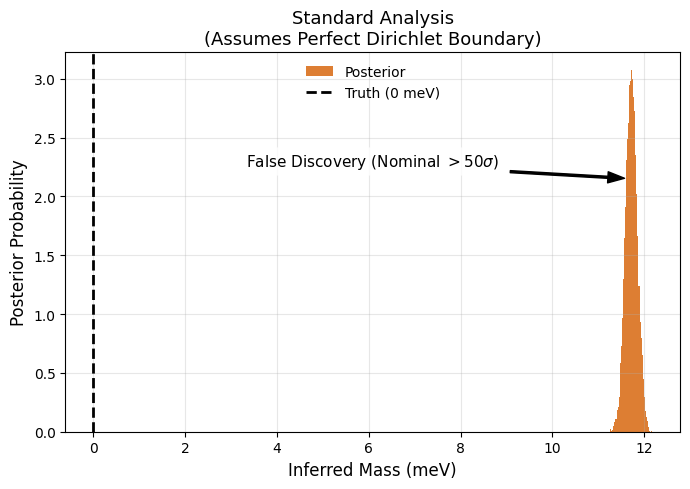

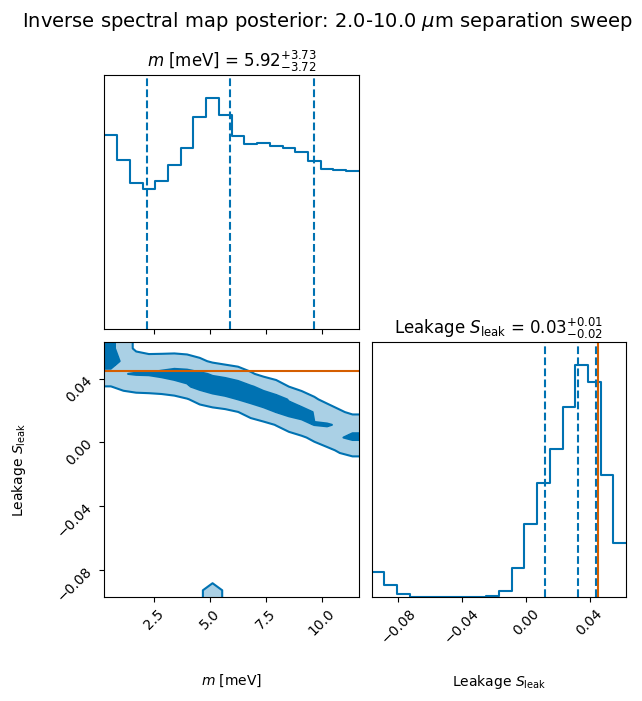

In [6]:
# =============================================================================
# 5. RESULTS & PLOTS
# =============================================================================
flat_std = sampler_std.get_chain(discard=200, flat=True)
flat_rob = sampler_rob.get_chain(discard=200, flat=True)

m_std_med = np.median(flat_std)
m_rob_med = np.median(flat_rob[:,0])
s_rob_med = np.median(flat_rob[:,1])

# --- ADDED: Compute Geometric Susceptibility (Chi_geo) ---
# Chi_geo = d(m_spur) / d(leakage) ~ m_spur / leakage_percent
# We assume TRUE_LEAKAGE is a fractional value (e.g., 0.045)
leakage_percent = TRUE_LEAKAGE * 100.0
chi_geo_est = m_std_med / leakage_percent

print("\n" + "="*50)
print(f"STANDARD FIT: Found Particle m = {m_std_med:.2f} meV")
print("              (FALSE DISCOVERY: Signal detected!)")
print("-" * 50)
print(f"INVERSE MAP:  Found Particle m = {m_rob_med:.2f} meV")
print(f"              Found Leakage    = {s_rob_med*100:.2f}% (True: {leakage_percent:.2f}%)")
print("              (Recovers truth within error bars)")
print("-" * 50)
print(f"DIAGNOSTIC:   Geometric Susceptibility")
print(f"              Chi_geo ~ {chi_geo_est:.2f} meV / %")
print(f"              (Sensitivity of mass to unmodeled leakage)")
print("="*50)

# --- PLOT 1: The False Discovery (Histogram) with Arrow ---
fig1, ax1 = plt.subplots(figsize=(7, 5))
n, bins, patches = ax1.hist(flat_std, bins=40, color='#D55E00', alpha=0.8, density=True, label='Posterior')
ax1.axvline(0.0, color='black', linestyle='--', linewidth=2, label="Truth (0 meV)")

# Calculate arrow target (the peak of the histogram)
peak_height = np.max(n)
peak_x = bins[np.argmax(n)]

# Add the Annotation Arrow
ax1.annotate(
    r'False Discovery (Nominal $>50\sigma$)',
    xy=(peak_x, peak_height * 0.7),     # Arrow tip (Data coordinates)
    xycoords='data',
    xytext=(0.5, 0.7),                 # Text position (Axes coordinates: 0.5=Center, 0.7=Top)
    textcoords='axes fraction',         # <--- This fixes the scaling issue
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11, ha='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8)
)

ax1.set_title("Standard Analysis\n(Assumes Perfect Dirichlet Boundary)", fontsize=13)
ax1.set_xlabel("Inferred Mass (meV)", fontsize=12)
ax1.set_ylabel("Posterior Probability", fontsize=12)

# Legend on the right
ax1.legend(loc='upper center', frameon=False, fontsize=10)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_trap.pdf', bbox_inches='tight')
plt.show()

# --- PLOT 2: The Resolution (Corner Plot) - Professional Colors ---
fig2 = plt.figure(figsize=(7, 7))

# Professional Blue for contours, Orange for Truth
# Smooth=1.0 makes the contours look less "blocky"
figure = corner.corner(
    flat_rob,
    labels=[r"$m$ [meV]", r"Leakage $S_{\rm leak}$"],
    truths=[0.0, TRUE_LEAKAGE],
    truth_color="#D55E00",  # Vermillion (High Contrast)
    color="#0072B2",        # Professional Blue
    smooth=1.0,             # Smooth contours
    smooth1d=1.0,           # Smooth histograms
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    range=[0.99, 0.99],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2.0)), # 1-sigma and 2-sigma
    plot_density=True,
    plot_datapoints=False,  # Cleaner look without points
    fill_contours=True,
    fig=fig2
)

# Add title slightly higher
plt.suptitle(rf"Inverse spectral map posterior: {SCALES_MICRONS[0]}-{SCALES_MICRONS[-1]} $\mu$m separation sweep", fontsize=14, y=1.02)
plt.savefig('fig2_resolution.pdf', bbox_inches='tight')
plt.show()

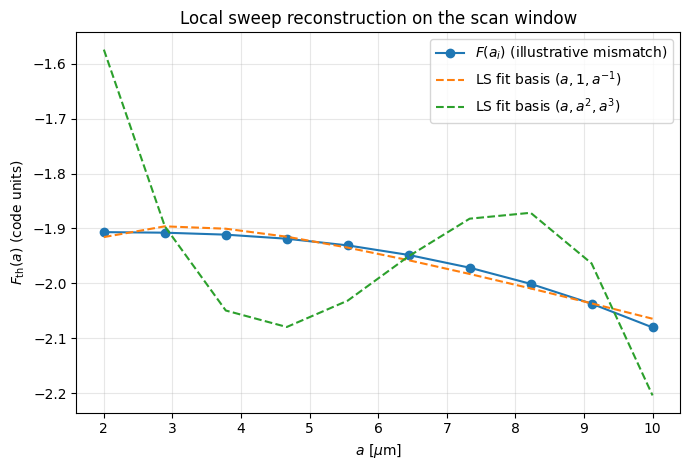

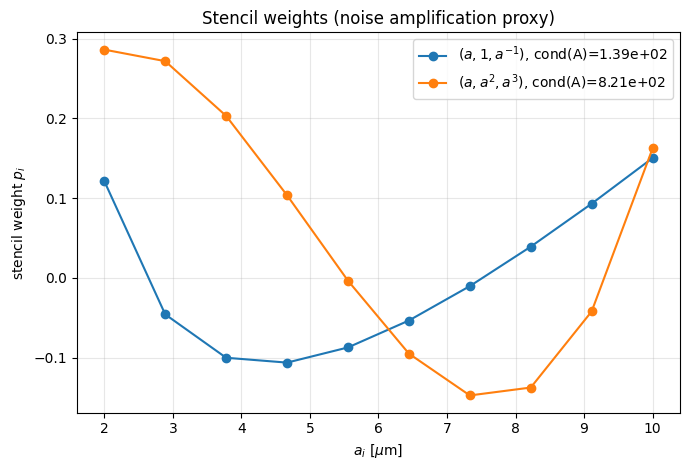

Condition numbers:
  cond(A) for (a,1,a^{-1}) = 139.49773026164792
  cond(A) for (a,a^2,a^3)  = 820.7073727754035


In [7]:
# =============================================================================
# 6. ADDITIONAL DIAGNOSTIC PLOTS: basis comparison and stencil weights
#    (Add this as a new cell; no changes to previous cells required.)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

def free_energy_sweep_unprojected(mass_code, spectrum, scales, beta):
    """
    Unprojected thermal free-energy sweep F(a_i) matching the forward model in predict_force_signal,
    but returning F_vals(a_i) instead of the projected dot-product.
    """
    nu2_shifted = spectrum[:, None] - 1.0  # same convention as in predict_force_signal
    w_sq = mass_code**2 + nu2_shifted / (scales[None, :]**2)
    w = np.sqrt(np.maximum(w_sq, 1e-15))
    term = np.exp(-beta * w)
    term = np.minimum(term, 0.99999999)
    return (1.0 / beta) * np.sum(np.log(1.0 - term), axis=0)

def fit_and_stencil(scales, y, basis="a_1_ainv"):
    """
    Fit y(a_i) with a chosen local basis and return:
    - fitted curve y_hat
    - coefficients beta_hat
    - stencil weights p (row that extracts the coefficient of 'a')
    - condition number of A
    """
    if basis == "a_1_ainv":
        A = np.vstack([scales, np.ones_like(scales), 1.0/scales]).T
    elif basis == "a_a2_a3":
        A = np.vstack([scales, scales**2, scales**3]).T
    else:
        raise ValueError("Unknown basis")
    beta_hat = np.linalg.pinv(A) @ y
    y_hat = A @ beta_hat
    p = np.linalg.pinv(A)[0, :]   # weights for coefficient of 'a'
    condA = np.linalg.cond(A)
    return y_hat, beta_hat, p, condA

# Choose a representative mass (use the truth by default)
m_plot_meV = TRUE_MASS_MEV
m_plot_code = m_plot_meV / INV_MICRON_TO_MEV

# Unprojected sweep
F_sweep = free_energy_sweep_unprojected(m_plot_code, SPEC_EXP, SCALES_MICRONS, BETA)

# For illustration we apply the same multiplicative mismatch on the sweep.
# (Linearity: scaling the sweep scales the projected statistic as well.)
F_sweep_eff = (1.0 - TRUE_LEAKAGE) * F_sweep

# Two alternative local bases
Fhat_A, beta_A, p_A, cond_A = fit_and_stencil(SCALES_MICRONS, F_sweep_eff, "a_1_ainv")
Fhat_B, beta_B, p_B, cond_B = fit_and_stencil(SCALES_MICRONS, F_sweep_eff, "a_a2_a3")

# --- Plot 1: sweep reconstruction ---
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(SCALES_MICRONS, F_sweep_eff, marker='o', linestyle='-', label=r'$F(a_i)$ (illustrative mismatch)')
ax.plot(SCALES_MICRONS, Fhat_A, linestyle='--', label=r'LS fit basis $(a,1,a^{-1})$')
ax.plot(SCALES_MICRONS, Fhat_B, linestyle='--', label=r'LS fit basis $(a,a^2,a^3)$')
ax.set_xlabel(r'$a\ [\mu{\rm m}]$')
ax.set_ylabel(r'$F_{\rm th}(a)$ (code units)')
ax.set_title('Local sweep reconstruction on the scan window')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_basis_fits.pdf', bbox_inches='tight')
plt.show()

# --- Plot 2: stencil weights (noise-amplification proxy) ---
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(SCALES_MICRONS, p_A, marker='o', linestyle='-', label=rf'$(a,1,a^{{-1}})$, cond(A)={cond_A:.2e}')
ax.plot(SCALES_MICRONS, p_B, marker='o', linestyle='-', label=rf'$(a,a^2,a^3)$, cond(A)={cond_B:.2e}')
ax.set_xlabel(r'$a_i\ [\mu{\rm m}]$')
ax.set_ylabel(r'stencil weight $p_i$')
ax.set_title('Stencil weights (noise amplification proxy)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_stencil_weights.pdf', bbox_inches='tight')
plt.show()

print("Condition numbers:")
print("  cond(A) for (a,1,a^{-1}) =", cond_A)
print("  cond(A) for (a,a^2,a^3)  =", cond_B)